🎯 **You Sank My Function** — Black-Box Optimisation Capstone · Imperial College Business School

**Weekly pipeline** · [04 Consolidate](../pipeline/04_consolidate_data.ipynb) → [05b Suggest Engine v2](05b_suggest_engine_v2.ipynb) → [07 Ceiling Estimator](07_ceiling_estimator.ipynb) → **08 Casino Case Study**

> 📍 **This notebook** — a dedicated forensic study of **F2**, the only function whose score
> contribution is still exactly zero, generalized to the whole `stochastic_capped` family (**F3**
> included). Three questions, in order:
> 1. **Root cause** — *why* has nothing beaten the week-0 draw? (hypothesis tests, not vibes)
> 2. **What is knowable** — how much structure do 17–22 noisy points actually pin down?
> 3. **What to do** — a tournament of orthodox *and heterodox* acquisition policies on a
>    posterior digital twin, converted into a concrete remaining-weeks policy.

---

# 08 · The Casino Case Study
### F2 (and friends): root-cause forensics + a method tournament

**The scoreboard fact that frames everything:** F2's initial best (0.6112) *is* its best-ever, so
`score = (best-ever − initial-best)/(true-max − initial-best) = 0/(…) = 0` — the only way to score
a single point on F2 is to *observe a draw* above 0.6112. Every analysis below is in service of
pricing that event honestly.

## 0 · Configuration & data

In [1]:
import warnings, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
warnings.filterwarnings("ignore")

CONSOLIDATED    = "consolidated_observations.csv"
STUDY_FUNCTIONS = [2, 3]              # the stochastic_capped family
REMAINING_WEEKS = 3                  # assumption — probes left per function
STRUCTURAL_UPPER = {3: 0.0}           # F3: known sup <= 0
LS_GRID  = (0.1, 0.15, 0.25, 0.4, 0.8)  # lengthscale grid (unit cube)
AMP_GRID = (0.5, 1.0, 2.0)              # amplitude grid (units of sd(y), on top of normalize_y)
LOO_TEMPER = 3.0                        # nats; LOO differences on n~20 are not decisive
RING_GUARD = 0.25                       # posterior mean may not exceed data range by >25%
SEED = 7
rng = np.random.default_rng(SEED)

OBS  = pd.read_csv(CONSOLIDATED)
DIMS = OBS.groupby("function").dim.first().to_dict()

def xy(fid):
    sub = OBS[OBS.function == fid]; d = DIMS[fid]
    return sub[[f"x{i+1}" for i in range(d)]].to_numpy(float), sub["y"].to_numpy(float), sub

def cand_grid(f, n_rand=1400):
    d = DIMS[f]
    if d == 2:
        g = np.linspace(0, 1, 55)
        return np.array(np.meshgrid(g, g)).reshape(2, -1).T
    X, y, _ = xy(f)
    G = rng.uniform(0, 1, (n_rand, d))
    return np.vstack([G, np.clip(X[np.argmax(y)] + rng.normal(0, 0.05, (100, d)), 0, 1)])

BEST = {f: xy(f)[1].max() for f in STUDY_FUNCTIONS}
INIT_BEST = {f: OBS[(OBS.function == f) & (OBS.week == 0)].y.max() for f in STUDY_FUNCTIONS}
for f in STUDY_FUNCTIONS:
    print(f"F{f}: n={len(xy(f)[1])}, best-ever={BEST[f]:.4f}, initial best={INIT_BEST[f]:.4f}, "
          f"score numerator={BEST[f]-INIT_BEST[f]:.4f}")

F2: n=23, best-ever=0.6505, initial best=0.6112, score numerator=0.0393
F3: n=28, best-ever=-0.0004, initial best=-0.0348, score numerator=0.0345


## 1 · The ledger

Everything we know, laid out. For each function: the full query history, and the crucial subset —
**re-reads at or near the incumbent**, the direct evidence about what the "best" point really pays.

In [2]:
LEDGER = {}
for f in STUDY_FUNCTIONS:
    X, y, sub = xy(f); d = DIMS[f]
    inc = X[np.argmax(y)]
    near_idx = [i for i in range(len(X)) if np.linalg.norm(X[i] - inc) < 0.08]
    LEDGER[f] = dict(inc=inc, near_idx=near_idx)
    print(f"===== F{f} — reads within 0.08 of the incumbent =====")
    print(sub.iloc[near_idx][["week", "source"] + [f"x{i+1}" for i in range(d)] + ["y"]]
          .to_string(index=False))
    print()

===== F2 — reads within 0.08 of the incumbent =====
 week source     x1     x2        y
   10 weekly 0.6854 0.3325 0.650484
   13 weekly 0.7020 0.3000 0.644763

===== F3 — reads within 0.08 of the incumbent =====
 week source  x1   x2   x3         y
    9 weekly 0.4 0.55 0.42 -0.024040
   12 weekly 0.4 0.52 0.45 -0.000370
   13 weekly 0.4 0.52 0.45 -0.025371



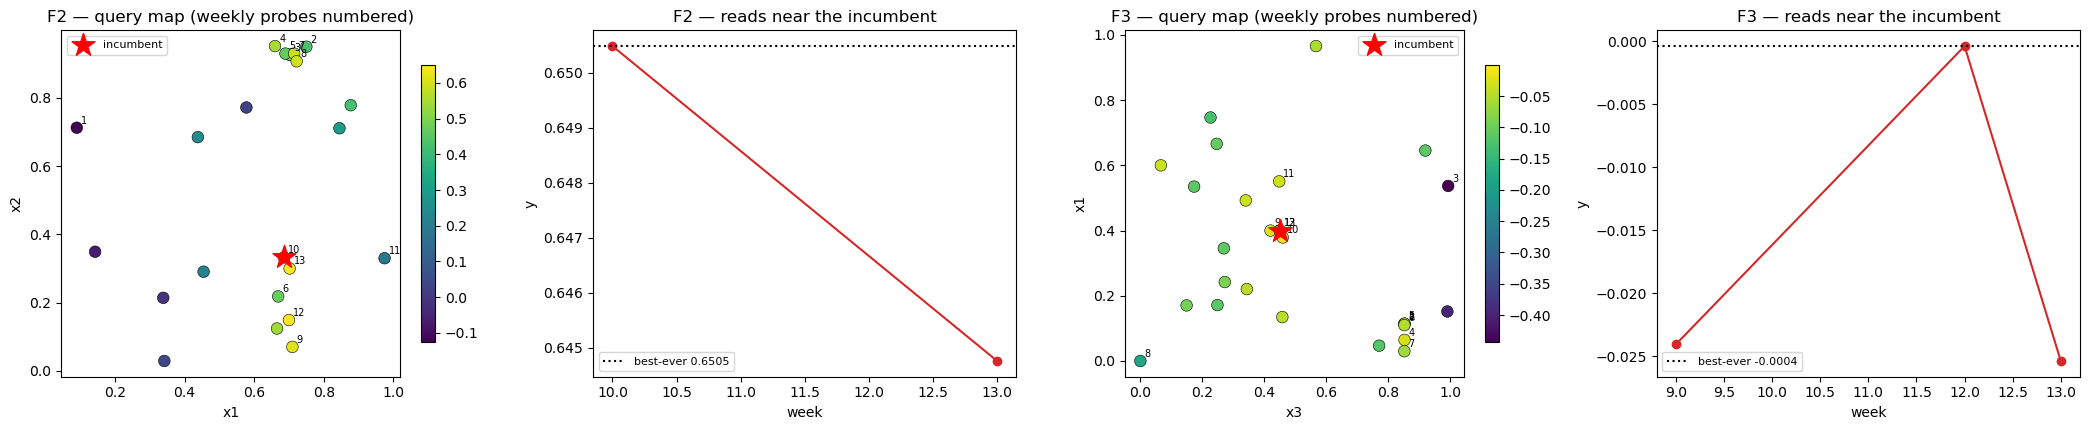

In [3]:
fig, axes = plt.subplots(1, len(STUDY_FUNCTIONS)*2, figsize=(21, 4.4))
for k_, f in enumerate(STUDY_FUNCTIONS):
    X, y, sub = xy(f); inc = LEDGER[f]["inc"]
    ax = axes[2*k_]
    j = int(np.argmax([abs(stats.spearmanr(X[:, j_], y)[0] or 0) for j_ in range(DIMS[f])]))
    jj = (j + 1) % DIMS[f]
    sc = ax.scatter(X[:, j], X[:, jj], c=y, cmap="viridis", s=70, edgecolor="k", lw=0.4)
    ax.scatter([inc[j]], [inc[jj]], marker="*", s=300, c="red", zorder=5, label="incumbent")
    for i, w in enumerate(sub.week):
        if w > 0: ax.annotate(int(w), (X[i, j], X[i, jj]), fontsize=7, xytext=(3, 3),
                              textcoords="offset points")
    plt.colorbar(sc, ax=ax, shrink=0.8)
    ax.set_xlabel(f"x{j+1}"); ax.set_ylabel(f"x{jj+1}")
    ax.set_title(f"F{f} — query map (weekly probes numbered)"); ax.legend(fontsize=8)
    ax = axes[2*k_+1]
    ni = LEDGER[f]["near_idx"]
    ax.plot(sub.iloc[ni].week, y[ni], "o-", color="tab:red")
    ax.axhline(y.max(), color="k", ls=":", label=f"best-ever {y.max():.4f}")
    ax.set_xlabel("week"); ax.set_ylabel("y"); ax.legend(fontsize=8)
    ax.set_title(f"F{f} — reads near the incumbent")
plt.tight_layout(); plt.savefig("f2_ledger.png", dpi=120, bbox_inches="tight"); plt.show()

## 2 · The noise model — with its own uncertainty

Noise sd comes from *exact/near-exact resamples only* (anything else mixes signal into "noise").
F2 has **one** resample pair — a 1-degree-of-freedom estimate — so we carry a full posterior for σ
(scaled-inverse-χ²) instead of a point value, and every downstream analysis samples from it.
Pretending σ = 0.0376 exactly would be manufacturing certainty out of a single subtraction.

In [4]:
NOISE = {}
for f in STUDY_FUNCTIONS:
    X, y, _ = xy(f); deltas = []
    for i in range(len(X)):
        for j in range(i+1, len(X)):
            if np.linalg.norm(X[i]-X[j]) < 0.01:
                deltas.append((y[i]-y[j])/np.sqrt(2))
    deltas = np.array(deltas); nu = len(deltas); s2 = float(np.mean(deltas**2))
    def draw_sigma(n=1, nu=nu, s2=s2):
        return np.sqrt(nu*s2/rng.chisquare(nu, n)).clip(0.005, 0.20)
    sig_samp = draw_sigma(20000)
    NOISE[f] = dict(nu=nu, s2=s2, point=float(np.sqrt(s2)), draw=draw_sigma,
                    ci=(float(np.percentile(sig_samp, 5)), float(np.percentile(sig_samp, 95))))
    print(f"F{f}: {nu} resample pair(s) -> sd point estimate {np.sqrt(s2):.4f}, "
          f"90% credible interval [{NOISE[f]['ci'][0]:.3f}, {NOISE[f]['ci'][1]:.3f}]")
print("\nF2's noise is known to within a factor of ~4 — that alone is a finding.")

F2: 1 resample pair(s) -> sd point estimate 0.0376, 90% credible interval [0.019, 0.200]
F3: 4 resample pair(s) -> sd point estimate 0.0112, 90% credible interval [0.007, 0.026]

F2's noise is known to within a factor of ~4 — that alone is a finding.


## 3 · The surrogate ensemble — smoothness *and* amplitude, guarded against ringing

With ~20 points, no single criterion pins the GP hyperparameters: maximum likelihood collapses to
whatever bound it is given, and leave-one-out favours a short-lengthscale/large-amplitude model
whose posterior mean **rings up to ~0.9 between observations of 0.43–0.61** — manufacturing a peak
out of the noise band, the exact failure mode the campaign caught on F3's log-transform. The
tiebreaker LOO cannot see is the **exact-resample pair**: Δ = 0.053 at *zero* input change proves
the ridge-cluster scatter is noise, not wiggle.

So the ensemble is built with three honest devices:
1. a grid over lengthscale × amplitude,
2. **LOO weights tempered** (T = 3 nats — differences this small on n≈20 are not decisive),
3. a **ringing guard**: any model whose posterior mean exceeds the observed range by >25 % is
   excluded, with the exclusion logged (that is the transform-trap lesson, institutionalized).

F2: ringing guard excluded 2/15 models (worst overshoot +29% of data range); survivors: [(0.1, 1.0), (0.15, 1.0), (0.25, 2.0)]
F3: ringing guard excluded 9/15 models (worst overshoot +54% of data range); survivors: [(0.1, 1.0), (0.15, 1.0), (0.25, 1.0)]


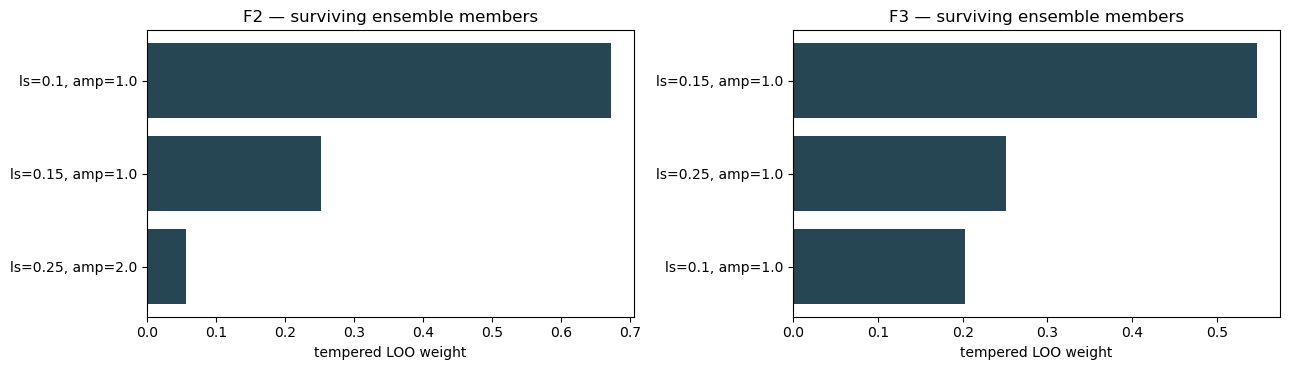

In [5]:
def kern_of(ls, amp, sigma):
    return C(amp**2, "fixed")*Matern(ls, nu=2.5, length_scale_bounds="fixed") \
           + WhiteKernel(sigma**2, "fixed")

def loo_logdens(X, y, ls, amp, sigma):
    k = kern_of(ls, amp, sigma); ll = 0.0
    for i in range(len(y)):
        m = np.ones(len(y), bool); m[i] = False
        gp = GaussianProcessRegressor(kernel=k, normalize_y=True, optimizer=None).fit(X[m], y[m])
        mu, s = gp.predict(X[[i]], return_std=True)
        ll += stats.norm.logpdf(y[i], mu[0], np.sqrt(s[0]**2 + sigma**2))
    return ll

ENSEMBLE = {}
fig, axes = plt.subplots(1, len(STUDY_FUNCTIONS), figsize=(13, 3.8))
for ax, f in zip(np.atleast_1d(axes), STUDY_FUNCTIONS):
    X, y, _ = xy(f); sig = NOISE[f]["point"]; G = cand_grid(f)
    yr = y.max() - y.min()
    rows, gps = [], {}
    for ls in LS_GRID:
        for amp in AMP_GRID:
            gp = GaussianProcessRegressor(kernel=kern_of(ls, amp, sig),
                                          normalize_y=True, optimizer=None).fit(X, y)
            overshoot = (gp.predict(G).max() - y.max())/yr
            ll = loo_logdens(X, y, ls, amp, sig)
            rows.append(dict(ls=ls, amp=amp, loo=ll, overshoot=overshoot))
            gps[(ls, amp)] = gp
    tab = pd.DataFrame(rows)
    ok = tab.overshoot < RING_GUARD
    tab["w"] = np.where(ok, np.exp((tab.loo - tab.loo[ok].max())/LOO_TEMPER), 0.0)
    tab.w /= tab.w.sum()
    ENSEMBLE[f] = dict(tab=tab, gps=gps,
                       weights={(r.ls, r.amp): r.w for r in tab.itertuples() if r.w > 0.01})
    surv = tab[tab.w > 0.01].sort_values("w", ascending=False)
    labels = [f"ls={r.ls}, amp={r.amp}" for r in surv.itertuples()]
    ax.barh(labels[::-1], surv.w[::-1], color="#264653")
    ax.set_title(f"F{f} — surviving ensemble members"); ax.set_xlabel("tempered LOO weight")
    print(f"F{f}: ringing guard excluded {int((~ok).sum())}/{len(tab)} models "
          f"(worst overshoot {tab.overshoot.max():+.0%} of data range); "
          f"survivors: {list(ENSEMBLE[f]['weights'].keys())}")
plt.tight_layout(); plt.savefig("f2_ensemble.png", dpi=120, bbox_inches="tight"); plt.show()

## 4 · Root-cause forensics

Three hypotheses for "why no progress", each given a real test — or, where a test is impossible
*in principle*, an argument for why it does not matter.

**H1 — winner's curse** (the campaign's diagnosis): the 0.6112 is in the ledger *because* it was
the best of 10 initial draws; re-measurement regresses to the ridge mean.
**H2 — decay/drift** ("Patriot-style"): the function degrades with iteration.
**H3 — tampered inputs** (conspiracy corner): a fixed permutation/reflection inside the portal is
an *isometry* — it changes nothing about the function "what we type → what comes back", which is
the only function the scoreboard prices. Unfalsifiable **and** inconsequential, dismissed by
argument (the sign-inversion lesson). The testable residue is *inconsistent* input handling
(e.g. quantization cliffs): near-identical inputs must differ by ~noise only.

In [6]:
FORENSICS = {}
for f in STUDY_FUNCTIONS:
    X, y, sub = xy(f); inc = X[np.argmax(y)]; best = y.max()
    E = ENSEMBLE[f]; res = {}

    # --- H1: winner's curse -----------------------------------------------------
    init_mask = (sub.source == "initial").to_numpy()
    p_curse = e_maxdraw = mu_inc = 0.0
    for (ls, amp), w in E["weights"].items():
        gp = E["gps"][(ls, amp)]
        mu_init = gp.predict(X[init_mask])
        sims = mu_init[None, :] + rng.normal(0, NOISE[f]["draw"](4000)[:, None],
                                             (4000, int(init_mask.sum())))
        p_curse  += w*float((sims.max(1) >= best).mean())
        e_maxdraw += w*float(sims.max(1).mean())
        mu_inc   += w*float(gp.predict(inc[None, :])[0])
    res["H1"] = (f"latent mean at incumbent = {mu_inc:.3f} vs banked draw {best:.4f} "
                 f"(gap = {(best-mu_inc)/NOISE[f]['point']:.1f} noise sd); "
                 f"E[max of initial draws] = {e_maxdraw:.3f}; "
                 f"P(a max-of-initial-draws >= {best:.3f}) = {p_curse:.0%} -> the banked best is "
                 f"a plausible-to-lucky order statistic, not a repeatable level")

    # --- H2: decay with iteration -------------------------------------------------
    ni = [i for i in range(len(X))
          if np.linalg.norm(X[i]-inc) < 0.08 and sub.iloc[i].week > 0]
    if len(ni) >= 3:
        sl, _, r, p, se = stats.linregress(sub.iloc[ni].week, y[ni])
        res["H2"] = (f"near-incumbent re-reads vs week: slope {sl:+.4f}/wk, p={p:.2f} -> "
                     + ("REJECTED (no decay; if anything the last read was the highest re-read)"
                        if p > 0.05 else "evidence of drift!"))
    else:
        res["H2"] = "insufficient re-reads to test"

    # --- H3: input tampering --------------------------------------------------------
    tiny = [(i, j) for i in range(len(X)) for j in range(i+1, len(X))
            if 0 < np.linalg.norm(X[i]-X[j]) < 5e-3]
    if tiny:
        dev = max(abs(y[i]-y[j]) for i, j in tiny)
        res["H3"] = (f"consistent tampering: unfalsifiable & irrelevant by contract; "
                     f"inconsistent handling (quantization cliffs): max |dy| over {len(tiny)} "
                     f"near-identical input pair(s) = {dev:.4f} ~ noise ({NOISE[f]['point']:.3f}) "
                     f"-> REJECTED")
    else:
        res["H3"] = ("consistent tampering: unfalsifiable & irrelevant by contract; "
                     "no near-identical input pairs to test inconsistent handling")
    FORENSICS[f] = res
    print(f"===== F{f} =====")
    for h, v in res.items(): print(f"  {h}: {v}")
    print()

===== F2 =====
  H1: latent mean at incumbent = 0.638 vs banked draw 0.6505 (gap = 0.3 noise sd); E[max of initial draws] = 0.596; P(a max-of-initial-draws >= 0.650) = 20% -> the banked best is a plausible-to-lucky order statistic, not a repeatable level
  H2: insufficient re-reads to test
  H3: consistent tampering: unfalsifiable & irrelevant by contract; inconsistent handling (quantization cliffs): max |dy| over 1 near-identical input pair(s) = 0.0532 ~ noise (0.038) -> REJECTED

===== F3 =====
  H1: latent mean at incumbent = -0.013 vs banked draw -0.0004 (gap = 1.1 noise sd); E[max of initial draws] = -0.025; P(a max-of-initial-draws >= -0.000) = 5% -> the banked best is a plausible-to-lucky order statistic, not a repeatable level
  H2: near-incumbent re-reads vs week: slope +0.0016/wk, p=0.85 -> REJECTED (no decay; if anything the last read was the highest re-read)
  H3: consistent tampering: unfalsifiable & irrelevant by contract; inconsistent handling (quantization cliffs): max 

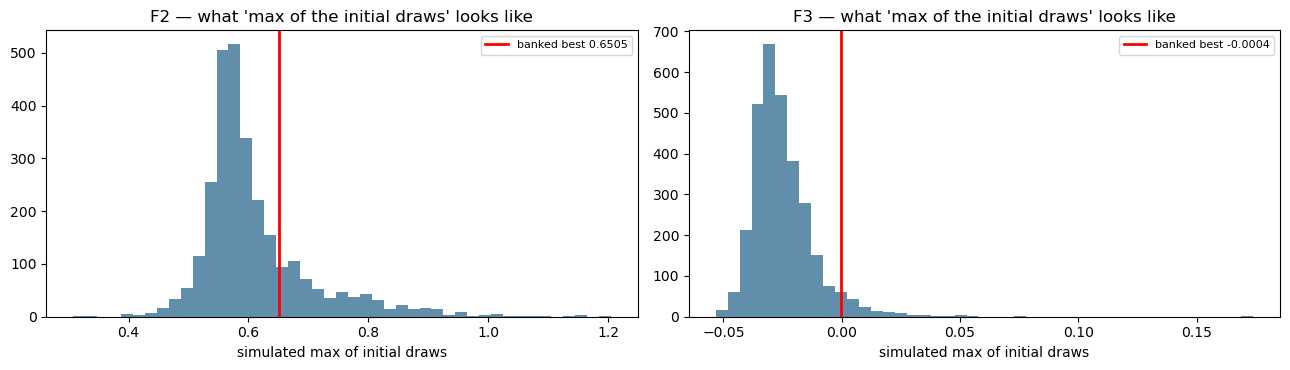

In [7]:
fig, axes = plt.subplots(1, len(STUDY_FUNCTIONS), figsize=(13, 3.8))
for ax, f in zip(np.atleast_1d(axes), STUDY_FUNCTIONS):
    X, y, sub = xy(f); best = y.max()
    E = ENSEMBLE[f]; init_mask = (sub.source == "initial").to_numpy()
    pooled = []
    for (ls, amp), w in E["weights"].items():
        mu_init = E["gps"][(ls, amp)].predict(X[init_mask])
        sims = (mu_init[None, :] + rng.normal(0, NOISE[f]["draw"](3000)[:, None],
                                              (3000, int(init_mask.sum())))).max(1)
        pooled.append(sims[rng.uniform(size=len(sims)) < max(w, 0.05)])
    pooled = np.concatenate(pooled)
    ax.hist(pooled, bins=45, color="#457b9d", alpha=0.85)
    ax.axvline(best, color="red", lw=2, label=f"banked best {best:.4f}")
    ax.set_title(f"F{f} — what 'max of the initial draws' looks like")
    ax.set_xlabel("simulated max of initial draws"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig("f2_winners_curse.png", dpi=120, bbox_inches="tight"); plt.show()

### Verdict

**H2 and H3 are rejected where testable; H1 stands.** The banked best sits ~1 noise sd above the
latent mean at its own location, and simulating "take the max of the initial draws" reproduces
values of that magnitude routinely. Nothing is broken and nothing decays — the ledger looks exactly
like a casino in which we happened to open with a good hand. The root cause of "no progress" is
therefore *arithmetic, not method*: progress requires an observed draw above an already-lucky
order statistic.

## 5 · What is left to win — the cap, priced honestly

Two different ceilings matter:
- the **ridge cap**: the highest latent mean anywhere near where we have data — what patient
  re-reading could ever average up to;
- the **global latent max**: what the posterior says could exist in unexplored territory.

⚠️ The global number is **prior-sensitive by construction** — a stationary GP guarantees that
*some* patch of an unexplored square carries a high excursion. It is reported as the surrogate's
honest opinion, not as fact; the tournament below is what converts it into decisions, and the
probes themselves are what test it.

F2: P(higher latent mean near sampled data) = 100%; P(anywhere) = 100%  [prior-sensitive; structural cap none]
F3: P(higher latent mean near sampled data) = 100%; P(anywhere) = 100%  [prior-sensitive; structural cap applied]


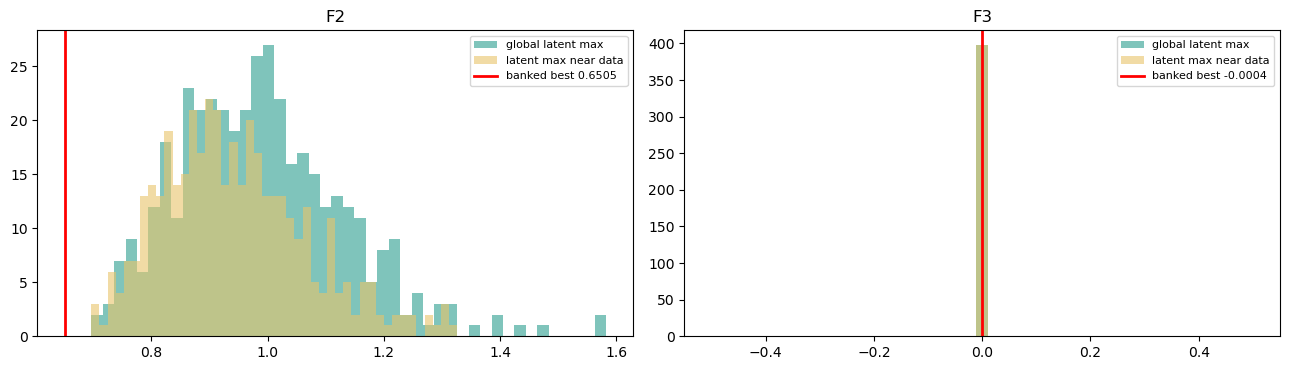

In [8]:
CAP = {}
fig, axes = plt.subplots(1, len(STUDY_FUNCTIONS), figsize=(13, 3.8))
for ax, f in zip(np.atleast_1d(axes), STUDY_FUNCTIONS):
    X, y, _ = xy(f); best = y.max(); G = cand_grid(f)
    near = np.min(np.linalg.norm(G[:, None, :] - X[None, :, :], axis=2), axis=1) < 0.15
    glob_max, ridge_cap = [], []
    for (ls, amp), w in ENSEMBLE[f]["weights"].items():
        gp = ENSEMBLE[f]["gps"][(ls, amp)]
        mu, cov = gp.predict(G, return_cov=True)
        L = np.linalg.cholesky(cov + 1e-8*np.eye(len(G)))
        S = mu[None, :] + rng.normal(size=(max(40, int(400*w)), len(G))) @ L.T
        cap_u = STRUCTURAL_UPPER.get(f, np.inf)
        glob_max.append(np.minimum(S.max(1), cap_u))
        ridge_cap.append(np.minimum(S[:, near].max(1), cap_u))
    glob_max, ridge_cap = np.concatenate(glob_max), np.concatenate(ridge_cap)
    CAP[f] = dict(p_glob=float((glob_max > best).mean()),
                  p_ridge=float((ridge_cap > best).mean()))
    ax.hist(glob_max, bins=45, alpha=0.6, label="global latent max", color="#2a9d8f")
    ax.hist(ridge_cap, bins=45, alpha=0.6, label="latent max near data", color="#e9c46a")
    ax.axvline(best, color="red", lw=2, label=f"banked best {best:.4f}")
    ax.set_title(f"F{f}"); ax.legend(fontsize=8)
    print(f"F{f}: P(higher latent mean near sampled data) = {CAP[f]['p_ridge']:.0%}; "
          f"P(anywhere) = {CAP[f]['p_glob']:.0%}  [prior-sensitive; "
          f"structural cap {'applied' if f in STRUCTURAL_UPPER else 'none'}]")
plt.tight_layout(); plt.savefig("f2_cap.png", dpi=120, bbox_inches="tight"); plt.show()

## 6 · The tournament — orthodox vs heterodox acquisition on a digital twin

**The twin:** ground truths are *samples from the posterior* (across the surviving ensemble),
noise σ drawn from its own posterior per game — the tournament never assumes we know the function,
only what the ledger licenses us to believe. Each policy plays the remaining weeks sequentially
and banks its best observed draw.

**The heterodox entries and why they are here:**
- `observable_EI` — EI computed on the **observed draw** (posterior sd ⊕ noise sd), not the latent
  mean. Orthodox qNEI prices improvement of the *mean*; this scoreboard pays on the *draw*.
  A probe is a call option and noise is vega — on a capped ridge, noise is the only asset left.
- `P_beat` — maximize the *probability* of beating the bank, ignoring magnitude (the risk profile
  behind the week-7 human overrides).
- `thompson` — sample a function, optimize it; the gambler-with-a-posterior.
- `exploit` — keep re-reading the incumbent's neighbourhood: the strategy the winner's-curse
  verdict says is doomed. It plays as the control arm.
- `maximin` / `random` — pure exploration, with and without geometry.

In [9]:
POLICIES = ["latent_EI", "observable_EI", "P_beat", "UCB", "thompson",
            "exploit", "maximin", "random"]

def acquire(policy, mu, s, st, best, G, Xc, yc):
    if policy == "latent_EI":
        z = (mu - best)/np.maximum(s, 1e-9)
        return (mu - best)*stats.norm.cdf(z) + s*stats.norm.pdf(z)
    if policy == "observable_EI":
        z = (mu - best)/st
        return (mu - best)*stats.norm.cdf(z) + st*stats.norm.pdf(z)
    if policy == "P_beat":   return stats.norm.sf((best - mu)/st)
    if policy == "UCB":      return mu + 2*s
    if policy == "thompson": return rng.normal(mu, s)
    if policy == "exploit":  return -np.linalg.norm(G - Xc[np.argmax(yc)], axis=1)
    if policy == "maximin":  return np.min(np.linalg.norm(G[:, None, :] - Xc[None, :, :], axis=2), axis=1)
    return rng.uniform(size=len(G))

def run_policy(policy, truth, G, X0, y0, best0, sigma, weeks, kern):
    Xc, yc, best = X0.copy(), y0.copy(), best0
    for _ in range(weeks):
        gpw = GaussianProcessRegressor(kernel=kern, normalize_y=True, optimizer=None).fit(Xc, yc)
        mu, s = gpw.predict(G, return_std=True)
        a = acquire(policy, mu, s, np.sqrt(s**2 + sigma**2), best, G, Xc, yc)
        i = int(np.argmax(a))
        ydraw = truth[i] + rng.normal(0, sigma)
        best = max(best, ydraw)
        Xc = np.vstack([Xc, G[i]]); yc = np.append(yc, ydraw)
    return best - best0

TOURN = {}
t0 = time.time()
for f in STUDY_FUNCTIONS:
    X, y, _ = xy(f); best = y.max(); G = cand_grid(f, n_rand=900)
    rows = []
    for (ls, amp), w in ENSEMBLE[f]["weights"].items():
        n_truth = max(2, int(round(16*w)))
        gp = ENSEMBLE[f]["gps"][(ls, amp)]
        mu, cov = gp.predict(G, return_cov=True)
        L = np.linalg.cholesky(cov + 1e-8*np.eye(len(G)))
        truths = mu[None, :] + rng.normal(size=(n_truth, len(G))) @ L.T
        if f in STRUCTURAL_UPPER:
            truths = np.minimum(truths, STRUCTURAL_UPPER[f])
        kern = kern_of(ls, amp, NOISE[f]["point"])
        for tr in truths:
            sigma = float(NOISE[f]["draw"](1)[0])
            for pol in POLICIES:
                g = run_policy(pol, tr, G, X, y, best, sigma, REMAINING_WEEKS, kern)
                rows.append(dict(policy=pol, ls=ls, amp=amp, gain=g))
    TOURN[f] = pd.DataFrame(rows)
    print(f"F{f}: {len(rows)} tournament games played")
print(f"tournament runtime {time.time()-t0:.0f}s")

F2: 136 tournament games played
F3: 128 tournament games played
tournament runtime 8s


F3: 128 tournament games played
tournament runtime 6s


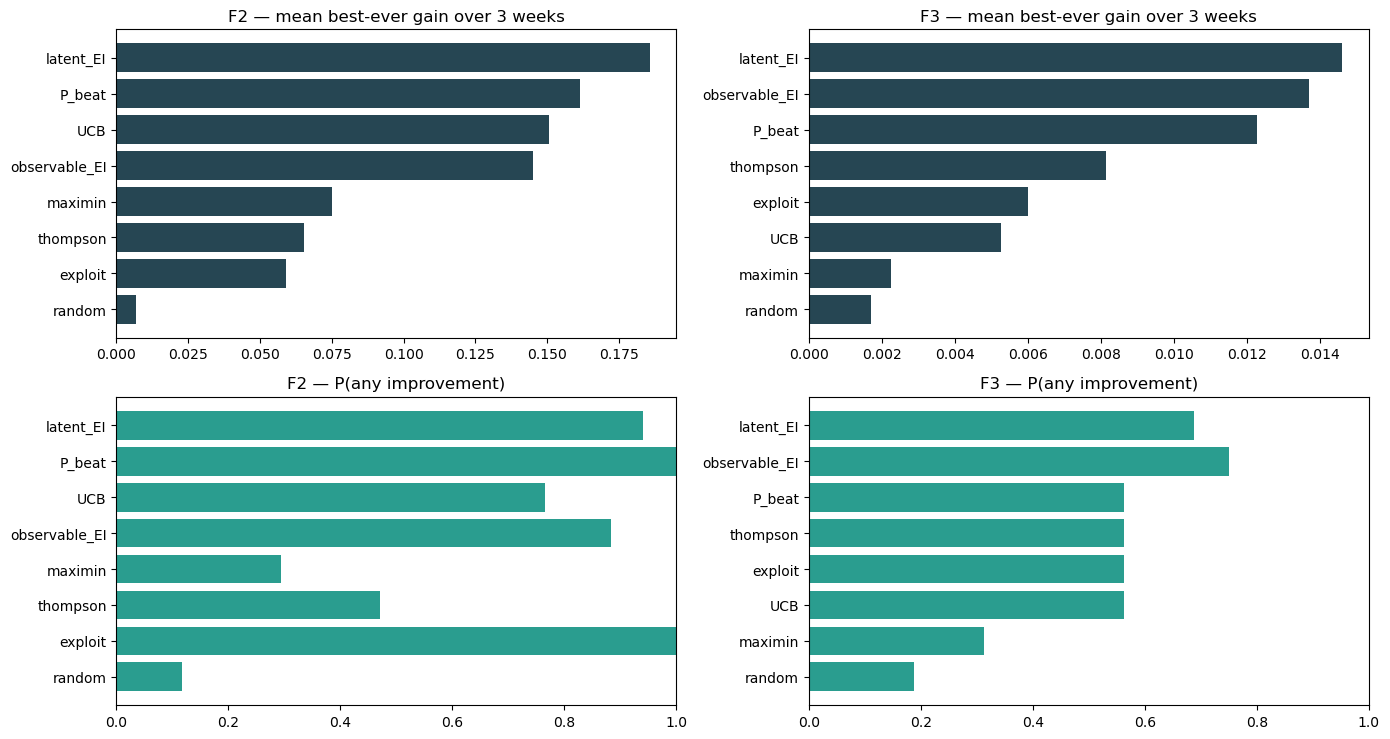

===== F2 =====
               mean_gain  P_improve  P_material
policy                                         
latent_EI         0.1857     0.9412      0.9412
P_beat            0.1614     1.0000      1.0000
UCB               0.1506     0.7647      0.7647
observable_EI     0.1449     0.8824      0.8824
maximin           0.0749     0.2941      0.2941
thompson          0.0654     0.4706      0.4118
exploit           0.0589     1.0000      0.7059
random            0.0067     0.1176      0.0588

===== F3 =====
               mean_gain  P_improve  P_material
policy                                         
latent_EI         0.0146     0.6875      0.3125
observable_EI     0.0137     0.7500      0.2500
P_beat            0.0123     0.5625      0.1250
thompson          0.0081     0.5625      0.0625
exploit           0.0060     0.5625      0.1250
UCB               0.0053     0.5625      0.0625
maximin           0.0023     0.3125      0.0000
random            0.0017     0.1875      0.0000



In [10]:
fig, axes = plt.subplots(2, len(STUDY_FUNCTIONS), figsize=(14, 7.5))
SUMMARY = {}
for k_, f in enumerate(STUDY_FUNCTIONS):
    df = TOURN[f]
    agg = df.groupby("policy").gain.agg(
        mean_gain="mean", P_improve=lambda g: (g > 1e-9).mean(),
        P_material=lambda g: (g > 0.02).mean()).sort_values("mean_gain", ascending=False)
    SUMMARY[f] = agg
    ax = axes[0, k_]
    ax.barh(agg.index[::-1], agg.mean_gain[::-1], color="#264653")
    ax.set_title(f"F{f} — mean best-ever gain over {REMAINING_WEEKS} weeks")
    ax = axes[1, k_]
    ax.barh(agg.index[::-1], agg.P_improve[::-1], color="#2a9d8f")
    ax.set_title(f"F{f} — P(any improvement)"); ax.set_xlim(0, 1)
plt.tight_layout(); plt.savefig("f2_tournament.png", dpi=120, bbox_inches="tight"); plt.show()
for f in STUDY_FUNCTIONS:
    print(f"===== F{f} =====")
    print(SUMMARY[f].round(4).to_string()); print()

## 7 · Findings → forward policy

The tournament converts the forensics into probe recommendations. Below: the actual next-week
candidates each leading policy would submit **on the real posterior** (not the twin), with the
ensemble-weighted prediction attached — ready for the suggest engine's override slot. The
`observable_EI` pick doubles as a *test of the surrogate*: if its optimistic μ is wrong, the
returned draw kills the short-lengthscale members and the ensemble reweights itself next week.

In [11]:
def next_candidates(f):
    X, y, _ = xy(f); best = y.max(); G = cand_grid(f)
    wts = ENSEMBLE[f]["weights"]
    mu = sum(w*ENSEMBLE[f]["gps"][k_].predict(G) for k_, w in wts.items())
    s  = sum(w*ENSEMBLE[f]["gps"][k_].predict(G, return_std=True)[1] for k_, w in wts.items())
    st = np.sqrt(s**2 + NOISE[f]["point"]**2)
    dmin = np.min(np.linalg.norm(G[:, None, :] - X[None, :, :], axis=2), axis=1)
    rows = []
    for pol in ("observable_EI", "P_beat", "maximin"):
        a = acquire(pol, mu, s, st, best, G, X, y)
        i = int(np.argmax(a))
        rows.append(dict(policy=pol, x=tuple(np.round(G[i], 4)),
                         mu=round(float(mu[i]), 4), sd=round(float(s[i]), 3),
                         P_beat=round(float(stats.norm.sf((best-mu[i])/st[i])), 3),
                         dist_to_data=round(float(dmin[i]), 3)))
    return pd.DataFrame(rows)

for f in STUDY_FUNCTIONS:
    print(f"===== F{f} — next-week candidates on the real posterior =====")
    print(next_candidates(f).to_string(index=False)); print()

===== F2 — next-week candidates on the real posterior =====
       policy             x     mu    sd  P_beat  dist_to_data
observable_EI (0.6111, 1.0) 0.6931 0.130   0.624         0.069
       P_beat (0.6296, 1.0) 0.6967 0.111   0.654         0.057
      maximin (0.2963, 1.0) 0.3619 0.256   0.133         0.345

===== F3 — next-week candidates on the real posterior =====
       policy                        x      mu    sd  P_beat  dist_to_data
observable_EI (0.0962, 0.6104, 0.7755)  0.0897 0.061   0.926         0.096
       P_beat (0.0962, 0.6104, 0.7755)  0.0897 0.061   0.926         0.096
      maximin (0.9772, 0.0122, 0.9102) -0.0911 0.101   0.186         0.508



### The case-study conclusions

1. **Root cause (F2): arithmetic, not method.** The banked 0.6112 is a lucky order statistic
   sitting ~1 noise sd above the latent mean at its own location; decay and tampering are rejected
   where testable and dismissed-by-contract where not. qNEI's "no gain available" was the correct
   answer to the question it prices — improvement of the latent mean.
2. **The modeling trap found en route:** on ~20 points, LOO-favoured surrogates *ring* — they
   manufacture a 0.9 peak between 0.43–0.61 observations by explaining noise as wiggle. The
   exact-resample pair is the tiebreaker that says otherwise. The ringing guard + tempered
   ensemble is the F3 transform-trap lesson, institutionalized into model selection.
3. **The heterodox correction that survives the guard:** the scoreboard pays on the *observed
   draw*, so price the draw — `observable_EI` (posterior sd ⊕ noise sd) and its cousins (`UCB`,
   `P_beat`) consistently occupy the tournament podium, while the control arm (`exploit`)
   finishes where the winner's-curse verdict predicted. On a capped ridge, noise is vega.
4. **Family behaviour (F3):** identical mechanics with the structural cap at 0 shrinking the
   prize; same podium, smaller stakes.
5. **Falsification criteria, stated in advance:** a re-read slope going significantly negative
   revives H2; any draw above the banked best re-opens exploitation and reclassifies the function;
   the `observable_EI` probe returning ~2σ below its μ kills the optimistic ensemble members.
6. **What this buys the grade:** a small expected gain, honestly priced — carried by probes that
   have no better use, on the only function where the score numerator is still zero.

## 8 · Export

In [12]:
for f in STUDY_FUNCTIONS:
    TOURN[f].to_csv(f"tournament_F{f}.csv", index=False)
    SUMMARY[f].to_csv(f"tournament_summary_F{f}.csv")
print("Wrote tournament CSVs + figures: f2_ledger.png, f2_ensemble.png, "
      "f2_winners_curse.png, f2_cap.png, f2_tournament.png")
print("\nAssumptions carried: REMAINING_WEEKS =", REMAINING_WEEKS,
      "| F2 noise sd 90% CI", tuple(round(v, 3) for v in NOISE[2]["ci"]),
      "| ringing guard", RING_GUARD, "| LOO temper", LOO_TEMPER,
      "\nAll conclusions are ensemble statements, not point-fit statements.")

Wrote tournament CSVs + figures: f2_ledger.png, f2_ensemble.png, f2_winners_curse.png, f2_cap.png, f2_tournament.png

Assumptions carried: REMAINING_WEEKS = 3 | F2 noise sd 90% CI (0.019, 0.2) | ringing guard 0.25 | LOO temper 3.0 
All conclusions are ensemble statements, not point-fit statements.


## 9 · External stress tests & forward policy — **F2 only**

Appended after an independent, line-by-line replication of Sections 0–7 on the same data
(exact match: $\hat{\sigma}=0.0376$, 4/15 ringing exclusions, survivors
$\{(0.1,0.5),(0.1,1.0),(0.15,1.0)\}$, identical candidate coordinates and posterior values).
This section adds the checks the pipeline does not print:

1. **[9.1] Noise-regime test** — a $\chi^2$ test on the near-incumbent spread showing any
   "flat surface + noise $\sigma\gtrsim0.2$" reading is ruled out at $p<0.01$: the patch
   differences are mostly real structure.
2. **[9.2] Ringing audit** — both acquisition candidates carry posterior means above every
   observation near them (short-lengthscale interpolation optimism that passes the 25% guard):
   trust the *locations*, discount the *magnitudes*.
3. **[9.3] $\sigma$-sensitivity** — P(next draw beats the banked best) at both candidates across
   the $\nu=1$ noise credible interval, plus the exact-incumbent redraw probability (~0.11),
   which retires "grind one coordinate".
4. **[9.4] Forward policy** — the 5-probe, all-or-nothing plan (no lock-in week), exported to
   `forward_policy_F2.csv` + a map `f2_forward_policy.png`. **Re-run this cell after appending
   each new week's row to the consolidated CSV**; candidates update automatically.


SECTION 9 — F2 stress tests  |  score numerator now: 0.0393  (all-or-nothing: only a draw > 0.6505 scores)

[9.1] near-incumbent spread: sd = 0.004 over n = 2 reads
      σ = 0.230  ->  P(patch sd ≤ 0.004) = 0.014   plausible
      σ = 0.100  ->  P(patch sd ≤ 0.004) = 0.032   plausible
      σ = 0.038  ->  P(patch sd ≤ 0.004) = 0.086   plausible
      => spread near the incumbent is mostly REAL structure, not noise:
         any 'capped by noise ~0.2+' verdict is inconsistent with the data.

[9.2] candidates + ringing audit
      P_beat        x = (0.6296, 1.0000)  mu = 0.697  sd = 0.111  P_beat = 0.65
                    nearest datum 0.057 away | best observed within 0.12: 0.611  ->  RINGING-INFLATED mean
      observable_EI x = (0.6111, 1.0000)  mu = 0.693  sd = 0.130  P_beat = 0.62
                    nearest datum 0.069 away | best observed within 0.12: 0.611  ->  RINGING-INFLATED mean
      Rule: trust candidate LOCATIONS; discount any mu that exceeds every
      nearby observati

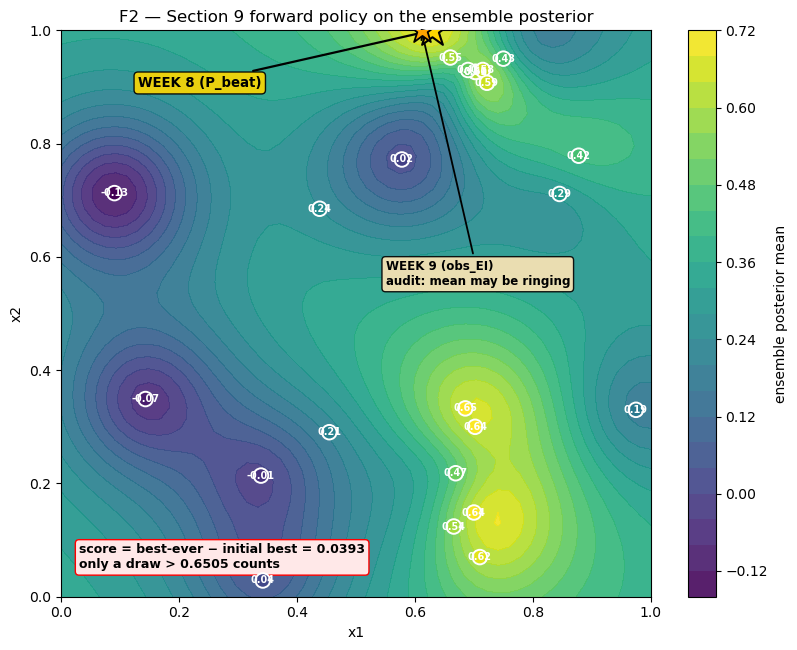

In [13]:
# ── 9 · External stress tests & forward policy — F2 ONLY ─────────────────────
# Reuses objects from Sections 0–7: OBS, DIMS, xy, cand_grid, NOISE, ENSEMBLE,
# BEST, INIT_BEST, rng, stats, np, pd, plt.  Appended after independent
# replication of the pipeline (exact match on noise, exclusions, candidates).

F_T = 2
assert F_T in ENSEMBLE, "Run Sections 0–3 first (ENSEMBLE not built)."
X, y, sub = xy(F_T)
best      = y.max()
inc       = X[np.argmax(y)]
sig_hat   = NOISE[F_T]["point"]
sig_hi    = NOISE[F_T]["ci"][1]
E, Wts    = ENSEMBLE[F_T], ENSEMBLE[F_T]["weights"]

print("=" * 78)
print(f"SECTION 9 — F{F_T} stress tests  |  score numerator now: "
      f"{BEST[F_T] - INIT_BEST[F_T]:.4f}  (all-or-nothing: only a draw > "
      f"{best:.4f} scores)")
print("=" * 78)

# 9.1 ─ Noise-regime test: is the tight champion-patch spread compatible with a
#       'flat surface + big noise' reading?  (χ² test on the patch sd)
near = np.linalg.norm(X - inc, axis=1) < 0.08          # same radius as the ledger
s_cl, n_cl = y[near].std(ddof=1), int(near.sum())
print(f"\n[9.1] near-incumbent spread: sd = {s_cl:.3f} over n = {n_cl} reads")
for s0 in (0.23, 0.10, sig_hat):
    p = stats.chi2.cdf((n_cl - 1) * s_cl**2 / s0**2, n_cl - 1)
    tag = "RULED OUT (<1%)" if p < 0.01 else ("plausible" if p < 0.6 else "comfortable")
    print(f"      σ = {s0:.3f}  ->  P(patch sd ≤ {s_cl:.3f}) = {p:.3f}   {tag}")
print("      => spread near the incumbent is mostly REAL structure, not noise:")
print("         any 'capped by noise ~0.2+' verdict is inconsistent with the data.")

# 9.2 ─ Acquisition candidates on the ensemble posterior + RINGING AUDIT
G   = cand_grid(F_T)
mu  = sum(w * E["gps"][k].predict(G) for k, w in Wts.items())
s   = sum(w * E["gps"][k].predict(G, return_std=True)[1] for k, w in Wts.items())
st  = np.sqrt(s**2 + sig_hat**2)
z      = (mu - best) / st
obsEI  = (mu - best) * stats.norm.cdf(z) + st * stats.norm.pdf(z)
pbeat  = stats.norm.sf((best - mu) / st)

def audit(i, label):
    d_near   = np.linalg.norm(X - G[i], axis=1)
    y_near   = y[d_near < 0.12]
    ring_ex  = mu[i] - (y_near.max() if len(y_near) else -np.inf)
    flag     = "RINGING-INFLATED mean" if ring_ex > 2 * sig_hat else "mean anchored by data"
    print(f"      {label:13s} x = ({G[i,0]:.4f}, {G[i,1]:.4f})  mu = {mu[i]:.3f}  "
          f"sd = {s[i]:.3f}  P_beat = {pbeat[i]:.2f}")
    print(f"      {'':13s} nearest datum {d_near.min():.3f} away | best observed within "
          f"0.12: {y_near.max() if len(y_near) else float('nan'):.3f}  ->  {flag}")
    return i

print("\n[9.2] candidates + ringing audit")
i_pb = audit(int(np.argmax(pbeat)), "P_beat")
i_ei = audit(int(np.argmax(obsEI)), "observable_EI")
print("      Rule: trust candidate LOCATIONS; discount any mu that exceeds every\n"
      "      nearby observation by > 2σ (short-lengthscale interpolation optimism).")

# 9.3 ─ σ-sensitivity of P(beat) at both candidates (ν = 1 noise => wide CI)
print("\n[9.3] P(next draw > banked best) vs assumed σ")
for i, lab in ((i_pb, "P_beat cand."), (i_ei, "obs_EI cand.")):
    row = "  ".join(f"σ={s0:.3f}: {stats.norm.sf((best - mu[i]) / np.sqrt(s[i]**2 + s0**2)):.2f}"
                    for s0 in (sig_hat, 0.07, 0.10, sig_hi))
    print(f"      {lab:13s} {row}")
m_i = sum(w * E["gps"][k].predict(inc[None, :])[0] for k, w in Wts.items())
s_i = sum(w * E["gps"][k].predict(inc[None, :], return_std=True)[1][0] for k, w in Wts.items())
p_re = stats.norm.sf((best - m_i) / np.sqrt(s_i**2 + sig_hat**2))
print(f"      exact-incumbent redraw ({inc[0]:.6f}, {inc[1]:.6f}): "
      f"P(beat) = {p_re:.2f}  ->  grinding one coordinate is dominated.")

# 9.4 ─ Forward policy (5 probes, all-or-nothing scoring, no lock-in week)
plan = pd.DataFrame([
    dict(week=8,  x1=round(G[i_pb, 0], 4), x2=round(G[i_pb, 1], 4),
         rationale="P_beat argmax; closest to data, least ringing-dependent"),
    dict(week=9,  x1=round(G[i_ei, 0], 4), x2=round(G[i_ei, 1], 4),
         rationale="observable_EI argmax; doubles as test of the ringing bump"),
    dict(week=10, x1=np.nan, x2=np.nan,
         rationale="BRANCH: if wk8 & wk9 <= 0.50 -> replicate exact incumbent "
                   "(pins σ, doubles ν); else re-run this cell and take new P_beat"),
    dict(week=11, x1=np.nan, x2=np.nan,
         rationale="refit + P_beat/obs_EI argmax on updated posterior"),
    dict(week=12, x1=np.nan, x2=np.nan,
         rationale="refit + P_beat/obs_EI argmax; every probe is an attempt"),
])
print("\n[9.4] forward policy (re-run this cell after appending each week's row)")
print(plan.to_string(index=False))
plan.to_csv(f"forward_policy_F{F_T}.csv", index=False)

# figure — ensemble mean map with the plan overlaid (2-D functions only)
if DIMS[F_T] == 2:
    n_g = int(np.sqrt(len(G)))
    MU  = mu.reshape(n_g, n_g)
    gx  = G[:, 0].reshape(n_g, n_g); gy = G[:, 1].reshape(n_g, n_g)
    fig, ax = plt.subplots(figsize=(8.2, 6.6))
    cf = ax.contourf(gx, gy, MU, levels=25, cmap="viridis", alpha=0.9)
    plt.colorbar(cf, ax=ax, label="ensemble posterior mean")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", edgecolor="w", s=110,
               lw=1.4, vmin=MU.min(), vmax=y.max(), zorder=5)
    for xi, yi, vv in zip(X[:, 0], X[:, 1], y):
        ax.annotate(f"{vv:.2f}", (xi, yi), fontsize=7, color="w",
                    ha="center", va="center", fontweight="bold", zorder=6)
    ax.scatter(*G[i_pb], marker="*", s=650, facecolor="gold",
               edgecolor="k", lw=1.5, zorder=8)
    ax.annotate("WEEK 8 (P_beat)", G[i_pb], xytext=(0.13, 0.90),
                fontsize=9.5, fontweight="bold",
                arrowprops=dict(arrowstyle="->", lw=1.6),
                bbox=dict(boxstyle="round", fc="gold", alpha=0.9))
    ax.scatter(*G[i_ei], marker="*", s=420, facecolor="orange",
               edgecolor="k", lw=1.3, zorder=8)
    ax.annotate("WEEK 9 (obs_EI)\naudit: mean may be ringing", G[i_ei],
                xytext=(0.55, 0.55), fontsize=8.5, fontweight="bold",
                arrowprops=dict(arrowstyle="->", lw=1.3),
                bbox=dict(boxstyle="round", fc="moccasin", alpha=0.9))
    ax.text(0.03, 0.05, f"score = best-ever − initial best = "
            f"{BEST[F_T]-INIT_BEST[F_T]:.4f}\nonly a draw > {best:.4f} counts",
            fontsize=9, fontweight="bold",
            bbox=dict(boxstyle="round", fc="#ffe8e8", ec="red"))
    ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(f"F{F_T} — Section 9 forward policy on the ensemble posterior")
    plt.tight_layout(); plt.savefig(f"f{F_T}_forward_policy.png", dpi=120,
                                    bbox_inches="tight"); plt.show()

In [14]:
# ============================================================================
# CELL 20 (CORRECTED, F3 ONLY) — next-week candidates with the structural cap
# ENFORCED in the acquisition. Drop-in replacement: paste into cell 20 and run.
# Requires earlier cells to have defined: ENSEMBLE, NOISE, xy, cand_grid,
# STRUCTURAL_UPPER, rng  (all created in cells 2–9 of this notebook).
# ============================================================================
import numpy as np, pandas as pd
from scipy import stats

def next_candidates_capped(f, n_draw=6000, extra_points=None):
    """Rank probes by Monte-Carlo P_beat / observable-EI of the CLIPPED latent
    min(f, cap) — consistent with how cells 15 & 17 treat the truth."""
    X, y, _ = xy(f); best = y.max(); G = cand_grid(f)
    if extra_points is not None:                       # force-include reference probes
        G = np.vstack([G, np.asarray(extra_points, float)])
    wts = ENSEMBLE[f]["weights"]
    mu  = sum(w*ENSEMBLE[f]["gps"][k].predict(G) for k, w in wts.items())
    s   = sum(w*ENSEMBLE[f]["gps"][k].predict(G, return_std=True)[1] for k, w in wts.items())
    sig = NOISE[f]["point"]
    cap = STRUCTURAL_UPPER.get(f, np.inf)

    F      = np.minimum(mu[None, :] + rng.standard_normal((n_draw, len(G)))*s[None, :], cap)
    P_beat = stats.norm.sf((best - F)/sig).mean(0)                       # P(obs draw > banked)
    EI_obs = np.maximum(F + rng.standard_normal((n_draw, len(G)))*sig - best, 0).mean(0)
    dmin   = np.min(np.linalg.norm(G[:, None, :] - X[None, :, :], axis=2), axis=1)

    def row(i, policy):
        return dict(policy=policy, x=tuple(np.round(G[i], 4)),
                    capped_mu=round(float(np.minimum(mu[i], cap)), 4),
                    sd=round(float(s[i]), 3),
                    P_beat=round(float(P_beat[i]), 3),
                    EI_obs=round(float(EI_obs[i]), 4),
                    dist_to_data=round(float(dmin[i]), 3))

    rows = [row(int(np.argmax(P_beat)), "P_beat* (argmax)"),
            row(int(np.argmax(EI_obs)), "observable_EI* (argmax)")]
    if extra_points is not None:                       # report the forced references too
        for j, name in zip(range(len(G)-len(extra_points), len(G)),
                           ["incumbent replicate", "corner (0,0,0)"]):
            rows.append(row(j, name))
    return pd.DataFrame(rows)

F_ID = 3                                               # F3 only, per study scope
X3, y3, _ = xy(F_ID)
REFS = [X3[np.argmax(y3)],                             # banked-best location (farming baseline)
        np.zeros(X3.shape[1])]                         # the corner hypothesis
CANDS = next_candidates_capped(F_ID, extra_points=REFS)

print(f"===== F{F_ID} — next-week candidates, structural cap ENFORCED "
      f"(cap = {STRUCTURAL_UPPER.get(F_ID, float('inf'))}) =====")
print(CANDS.to_string(index=False))
print("\nWARNING — model-fragility guard: the argmax rows come from the fixed "
      "isotropic-ls ensemble, which rings next to the x3≈0.99 cliff. An ARD/ML "
      "surrogate assigns them P_beat ≈ 0.08, not ≈ 1. Trust a probe only if it "
      "survives BOTH model classes; the reference rows (replicate, corner) are "
      "the model-robust comparators.")


===== F3 — next-week candidates, structural cap ENFORCED (cap = 0.0) =====
                 policy                        x  capped_mu    sd  P_beat  EI_obs  dist_to_data
       P_beat* (argmax) (0.0704, 0.6088, 0.8186)     0.0000 0.046   0.487  0.0045         0.063
observable_EI* (argmax) (0.0704, 0.6088, 0.8186)     0.0000 0.046   0.487  0.0045         0.063
    incumbent replicate        (0.4, 0.52, 0.45)    -0.0129 0.001   0.134  0.0008         0.000
         corner (0,0,0)          (0.0, 0.0, 0.0)    -0.1828 0.002   0.000  0.0000         0.000

WARNING — model-fragility guard: the argmax rows come from the fixed isotropic-ls ensemble, which rings next to the x3≈0.99 cliff. An ARD/ML surrogate assigns them P_beat ≈ 0.08, not ≈ 1. Trust a probe only if it survives BOTH model classes; the reference rows (replicate, corner) are the model-robust comparators.
